# Connect Google Drive

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import torch
print(f"Is CUDA available? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Is CUDA available? True
GPU Name: NVIDIA L4


# Install **pytorch-tabnet, optuna**

In [3]:
!pip install pytorch-tabnet optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 39.0 MB/s eta 0:00:00


# Important Libraries

In [4]:
import torch
import shap
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from pytorch_tabnet.metrics import Metric
from pytorch_tabnet.tab_model import TabNetRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
import joblib
import os
import gc

# Sentinel-2

## Data Loading


In [5]:
s2_file_path = "/content/drive/MyDrive/Thesis/Train_data/s2_with_veg_data.csv"

print("Loading data...")
s2df = pd.read_csv(s2_file_path)
print("Data is loaded")

print("\nData preparation...")

s2df1 = s2df.loc[s2df["age"] != 5].dropna()

s2df1.drop(columns=["age", "stock_per_ha", "basal_area", "poly_id", "S2_Date"], axis=1, inplace=True)

s2_y = s2df1["height"]
S2_X = s2df1.drop(columns=["height"], axis=1)

S2_train, S2_val, s2_train, s2_val = train_test_split(S2_X, s2_y, test_size=0.15, random_state=42, stratify=s2_y)
S2_train, S2_test, s2_train, s2_test = train_test_split(S2_train, s2_train, test_size=0.15, random_state=42, stratify=s2_train)

print(f"\nDatasets are read! S2_train shape: {S2_train.shape}, S2_test shape: {S2_test.shape}, S2_val shape: {S2_val.shape}")

Loading data...
Data is loaded

Data preparation...

Datasets are read! S2_train shape: (284286, 52), S2_test shape: (50169, 52), S2_val shape: (59022, 52)


## Training with optimized Hyper-parameters


### XGBoost Model Training, Evaluation and Plot


Starting XGBoost training...
[0]	validation_0-rmse:4.03241
[1]	validation_0-rmse:4.02140
[2]	validation_0-rmse:4.01090
[3]	validation_0-rmse:4.00009
[4]	validation_0-rmse:3.98930
[5]	validation_0-rmse:3.97858
[6]	validation_0-rmse:3.96835
[7]	validation_0-rmse:3.95850
[8]	validation_0-rmse:3.94835
[9]	validation_0-rmse:3.93844
[10]	validation_0-rmse:3.92887
[11]	validation_0-rmse:3.91914
[12]	validation_0-rmse:3.90967
[13]	validation_0-rmse:3.90033
[14]	validation_0-rmse:3.89116
[15]	validation_0-rmse:3.88196
[16]	validation_0-rmse:3.87282
[17]	validation_0-rmse:3.86376
[18]	validation_0-rmse:3.85529
[19]	validation_0-rmse:3.84647
[20]	validation_0-rmse:3.83816
[21]	validation_0-rmse:3.82966
[22]	validation_0-rmse:3.82142
[23]	validation_0-rmse:3.81314
[24]	validation_0-rmse:3.80511
[25]	validation_0-rmse:3.79691
[26]	validation_0-rmse:3.78921
[27]	validation_0-rmse:3.78180
[28]	validation_0-rmse:3.77435
[29]	validation_0-rmse:3.76698
[30]	validation_0-rmse:3.76014
[31]	validation_0-r

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [16:47:01] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Final Model RMSE: 3.101
Final Model MAE: 2.369


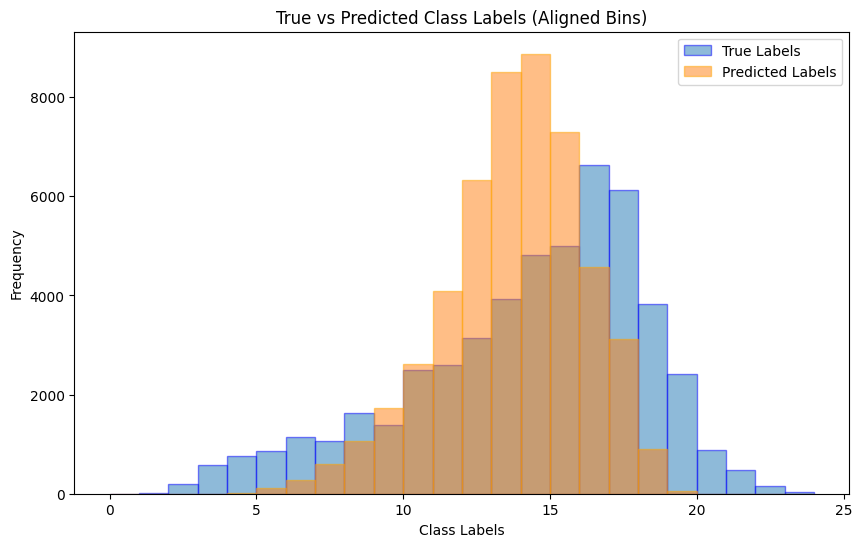

In [6]:
print("\nStarting XGBoost training...")
# Best Regressor Params:
# {'subsample': 0.7,
# 'n_estimators': 2000,
# 'min_child_weight': 7,
# 'max_depth': 15,
# 'learning_rate': 0.01,
# 'gamma': 0.5,
# 'colsample_bytree': 0.7}

XGBmodel_height = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    tree_method='hist',
    n_estimators=2000,
    max_depth = 15,
    learning_rate = 0.01,
    colsample_bytree = 0.7,
    subsample = 0.7,
    min_child_weight = 7,
    gamma = 0.5,
    device="cuda",
    early_stopping_rounds=50
)

XGBmodel_height.fit(
    S2_train, s2_train,
    eval_set=[(S2_val, s2_val)]
)
print("XGBoost Training finished")

# Evaluate
print("\nEvaluating Final Hurdle Model on Test Set...")
y_pred_final = XGBmodel_height.predict(S2_test)

rmse_final = np.sqrt(mean_squared_error(s2_test, y_pred_final))
mae_final = mean_absolute_error(s2_test, y_pred_final)

print(f"Final Model RMSE: {rmse_final:.3f}")
print(f"Final Model MAE: {mae_final:.3f}")

# Plot
plt.figure(figsize=(10, 6))
shared_bins = np.arange(0, 25, 1)

plt.hist(s2_test, label='True Labels', alpha=0.5, bins=shared_bins, edgecolor='blue')
plt.hist(y_pred_final, label='Predicted Labels', alpha=0.5, bins=shared_bins, edgecolor='orange')

plt.xlabel('Class Labels')
plt.ylabel('Frequency')
plt.legend()
plt.title('True vs Predicted Class Labels (Aligned Bins)')
plt.show()

### Tabnet Model Training, Evaluation and Plot

In [8]:
S2_train_np = S2_train.values.astype(np.float32) if isinstance(S2_train, pd.DataFrame) else S2_train.astype(np.float32)
s2_train_np = s2_train.values.astype(np.float32).reshape(-1, 1) if isinstance(s2_train, pd.Series) else s2_train.astype(np.float32).reshape(-1, 1)

S2_val_np = S2_val.values.astype(np.float32) if isinstance(S2_val, pd.DataFrame) else S2_val.astype(np.float32)
s2_val_np = s2_val.values.astype(np.float32).reshape(-1, 1) if isinstance(s2_val, pd.Series) else s2_val.astype(np.float32).reshape(-1, 1)

S2_test_np = S2_test.values.astype(np.float32) if isinstance(S2_test, pd.DataFrame) else S2_test.astype(np.float32)
s2_test_np = s2_test.values.astype(np.float32).reshape(-1, 1) if isinstance(s2_test, pd.Series) else s2_test.astype(np.float32).reshape(-1, 1)

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 27.23946| valid_rmse: 4.00713 |  0:00:05s
epoch 1  | loss: 12.07483| valid_rmse: 4.08872 |  0:00:11s
epoch 2  | loss: 11.39835| valid_rmse: 4.00271 |  0:00:16s
epoch 3  | loss: 11.0761 | valid_rmse: 4.2912  |  0:00:21s
epoch 4  | loss: 10.90015| valid_rmse: 3.93092 |  0:00:27s
epoch 5  | loss: 10.70664| valid_rmse: 3.55076 |  0:00:32s
epoch 6  | loss: 10.57063| valid_rmse: 3.68023 |  0:00:38s
epoch 7  | loss: 10.54177| valid_rmse: 3.41447 |  0:00:43s
epoch 8  | loss: 10.33713| valid_rmse: 3.41179 |  0:00:49s
epoch 9  | loss: 10.2574 | valid_rmse: 3.32435 |  0:00:54s
epoch 10 | loss: 10.15534| valid_rmse: 3.33089 |  0:01:00s
epoch 11 | loss: 10.01295| valid_rmse: 3.2939  |  0:01:05s
epoch 12 | loss: 9.94334 | valid_rmse: 3.17688 |  0:01:11s
epoch 13 | loss: 9.83446 | valid_rmse: 3.17954 |  0:01:16s
epoch 14 | loss: 9.74815 | valid_rmse: 3.13315 |  0:01:22s
epoch 15 | loss: 9.69536 | valid_rmse: 3.15119 |  0:01:27s
epoch 16 | loss: 9.74475 | valid_rmse: 3.16472 |  0:01:3

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Evaluating Final Model on Test Set...
Final Tabnet Model RMSE: 2.989
Final Tabnet Model MAE: 2.244


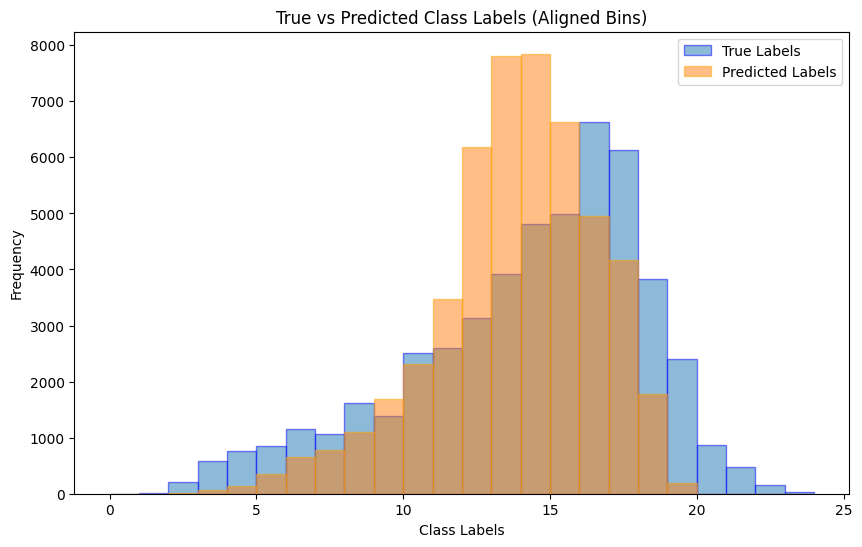

In [11]:
# Best Parameters Found:
#   n_d: 48
#   n_steps: 3
#   gamma: 1.1484990857274557
#   lambda_sparse: 2.203640606782299e-05
#   lr: 0.032174279968699857


Tabnet_height = TabNetRegressor(
    n_d= 48,
    n_a= 48,
    n_steps= 3,
    gamma= 1.1484990857274557,
    lambda_sparse= 2.203640606782299e-05,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.032174279968699857),
    mask_type='entmax',
    device_name='cuda',
    verbose=1
)

Tabnet_height.fit(
    X_train=S2_train_np, y_train=s2_train_np,
    eval_set=[(S2_val_np, s2_val_np)],
    eval_name=['valid'],
    eval_metric=['rmse'],
    max_epochs=150,
    patience=20,
    batch_size=4096,
    virtual_batch_size=512
)

# Evaluate
print("\nEvaluating Final Model on Test Set...")
y_pred_final = Tabnet_height.predict(S2_test_np)

rmse_final = np.sqrt(mean_squared_error(s2_test_np, y_pred_final))
mae_final = mean_absolute_error(s2_test_np, y_pred_final)

print(f"Final Tabnet Model RMSE: {rmse_final:.3f}")
print(f"Final Tabnet Model MAE: {mae_final:.3f}")

# Plot
plt.figure(figsize=(10, 6))

# Force bins to be exactly 0, 1, 2, ..., 24
shared_bins = np.arange(0, 25, 1)

plt.hist(s2_test_np, label='True Labels', alpha=0.5, bins=shared_bins, edgecolor='blue')
plt.hist(y_pred_final, label='Predicted Labels', alpha=0.5, bins=shared_bins, edgecolor='orange')

plt.xlabel('Class Labels')
plt.ylabel('Frequency')
plt.legend()
plt.title('True vs Predicted Class Labels (Aligned Bins)')
plt.show()

# Alpha Earth Foundation + Sentinel-2

## Data Loading

In [5]:
aef_file_path = "/content/drive/MyDrive/Thesis/Train_data/s2_aef_with_veg_data.csv"

print("Loading data...")
aefdf = pd.read_csv(aef_file_path)
print("Data is loaded")

print("\nData preparation...")

aefdf1 = aefdf.loc[aefdf["age"] != 5].dropna()

aefdf1.drop(columns=["age", "stock_per_ha", "basal_area", "poly_id", "S2_Date"], axis=1, inplace=True)

aef_y = aefdf1["height"]
AEF_X = aefdf1.drop(columns=["height"], axis=1)

AEF_train, AEF_val, aef_train, aef_val = train_test_split(AEF_X, aef_y, test_size=0.15, random_state=42, stratify=aef_y)
AEF_train, AEF_test, aef_train, aef_test = train_test_split(AEF_train, aef_train, test_size=0.15, random_state=42, stratify=aef_train)

print(f"\nDatasets are read! AEF_train shape: {AEF_train.shape}, AEF_test shape: {AEF_test.shape}, AEF_val shape: {AEF_val.shape}")

Loading data...
Data is loaded

Data preparation...

Datasets are read! AEF_train shape: (284117, 308), AEF_test shape: (50139, 308), AEF_val shape: (58987, 308)


##Training with optimized Hyper-parameters

### XGBoost Model Training, Evaluation and Plot


Starting XGBoost training...
[0]	validation_0-rmse:3.88566
[1]	validation_0-rmse:3.74805
[2]	validation_0-rmse:3.62774
[3]	validation_0-rmse:3.52402
[4]	validation_0-rmse:3.43517
[5]	validation_0-rmse:3.35674
[6]	validation_0-rmse:3.28745
[7]	validation_0-rmse:3.22691
[8]	validation_0-rmse:3.17466
[9]	validation_0-rmse:3.12943
[10]	validation_0-rmse:3.08906
[11]	validation_0-rmse:3.05374
[12]	validation_0-rmse:3.02177
[13]	validation_0-rmse:2.99414
[14]	validation_0-rmse:2.96775
[15]	validation_0-rmse:2.94507
[16]	validation_0-rmse:2.92390
[17]	validation_0-rmse:2.90544
[18]	validation_0-rmse:2.88795
[19]	validation_0-rmse:2.87161
[20]	validation_0-rmse:2.85651
[21]	validation_0-rmse:2.84299
[22]	validation_0-rmse:2.82922
[23]	validation_0-rmse:2.81668
[24]	validation_0-rmse:2.80618
[25]	validation_0-rmse:2.79501
[26]	validation_0-rmse:2.78566
[27]	validation_0-rmse:2.77605
[28]	validation_0-rmse:2.76496
[29]	validation_0-rmse:2.75699
[30]	validation_0-rmse:2.74866
[31]	validation_0-r

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [17:42:29] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Final Model RMSE: 1.689
Final Model MAE: 1.138


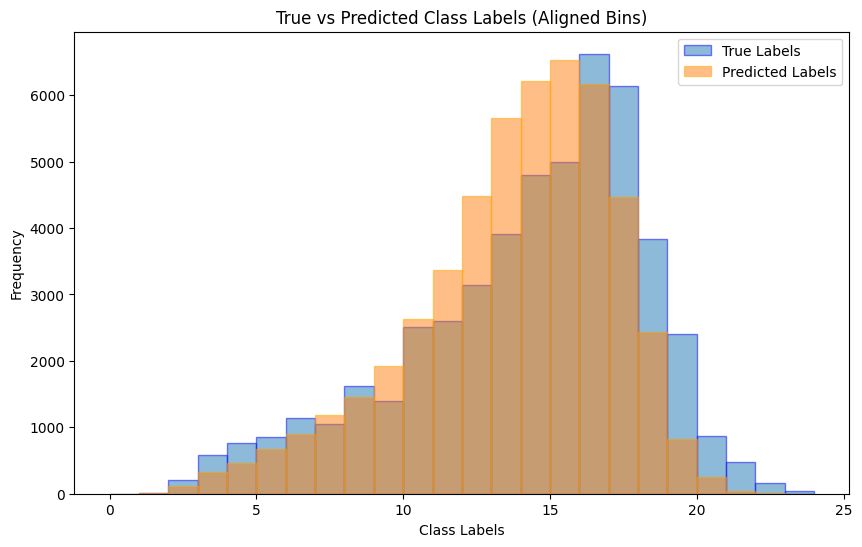

In [6]:
print("\nStarting XGBoost training...")
# Best Regressor Params:
# {'subsample': 0.9,
# 'n_estimators': 2000,
# 'min_child_weight': 7,
# 'max_depth': 9,
# 'learning_rate': 0.1,
# 'gamma': 0.1,
# 'colsample_bytree': 0.9}

XGBmodel_height = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    tree_method='hist',
    n_estimators=2000,
    max_depth = 9,
    learning_rate = 0.1,
    colsample_bytree = 0.9,
    subsample = 0.9,
    min_child_weight = 7,
    gamma = 0.1,
    device="cuda",
    early_stopping_rounds=50
)

XGBmodel_height.fit(
    AEF_train, aef_train,
    eval_set=[(AEF_val, aef_val)]
)
print("XGBoost Training finished")

# Evaluate
print("\nEvaluating Final Model on Test Set...")
y_pred_final = XGBmodel_height.predict(AEF_test)

rmse_final = np.sqrt(mean_squared_error(aef_test, y_pred_final))
mae_final = mean_absolute_error(aef_test, y_pred_final)

print(f"Final Model RMSE: {rmse_final:.3f}")
print(f"Final Model MAE: {mae_final:.3f}")

# Plot
plt.figure(figsize=(10, 6))
shared_bins = np.arange(0, 25, 1)

plt.hist(aef_test, label='True Labels', alpha=0.5, bins=shared_bins, edgecolor='blue')
plt.hist(y_pred_final, label='Predicted Labels', alpha=0.5, bins=shared_bins, edgecolor='orange')

plt.xlabel('Class Labels')
plt.ylabel('Frequency')
plt.legend()
plt.title('True vs Predicted Class Labels (Aligned Bins)')
plt.show()

### Tabnet Model Training, Evaluation and Plot

In [7]:
AEF_train_np = AEF_train.values.astype(np.float32) if isinstance(AEF_train, pd.DataFrame) else AEF_train.astype(np.float32)
aef_train_np = aef_train.values.astype(np.float32).reshape(-1, 1) if isinstance(aef_train, pd.Series) else aef_train.astype(np.float32).reshape(-1, 1)

AEF_val_np = AEF_val.values.astype(np.float32) if isinstance(AEF_val, pd.DataFrame) else AEF_val.astype(np.float32)
aef_val_np = aef_val.values.astype(np.float32).reshape(-1, 1) if isinstance(aef_val, pd.Series) else aef_val.astype(np.float32).reshape(-1, 1)

AEF_test_np = AEF_test.values.astype(np.float32) if isinstance(AEF_test, pd.DataFrame) else AEF_test.astype(np.float32)
aef_test_np = aef_test.values.astype(np.float32).reshape(-1, 1) if isinstance(aef_test, pd.Series) else aef_test.astype(np.float32).reshape(-1, 1)

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 22.80619| valid_rmse: 3.90298 |  0:00:07s
epoch 1  | loss: 8.60471 | valid_rmse: 3.742   |  0:00:14s
epoch 2  | loss: 7.94179 | valid_rmse: 3.63428 |  0:00:20s
epoch 3  | loss: 7.51032 | valid_rmse: 3.52887 |  0:00:27s
epoch 4  | loss: 7.13474 | valid_rmse: 3.35128 |  0:00:33s
epoch 5  | loss: 6.78356 | valid_rmse: 3.12042 |  0:00:40s
epoch 6  | loss: 6.46073 | valid_rmse: 2.90408 |  0:00:47s
epoch 7  | loss: 6.17672 | valid_rmse: 2.81888 |  0:00:53s
epoch 8  | loss: 5.82508 | valid_rmse: 2.76445 |  0:00:59s
epoch 9  | loss: 5.48201 | valid_rmse: 2.62432 |  0:01:06s
epoch 10 | loss: 5.17266 | valid_rmse: 2.44752 |  0:01:13s
epoch 11 | loss: 4.81924 | valid_rmse: 2.38344 |  0:01:19s
epoch 12 | loss: 4.52315 | valid_rmse: 2.33083 |  0:01:26s
epoch 13 | loss: 4.3828  | valid_rmse: 2.21776 |  0:01:32s
epoch 14 | loss: 4.0191  | valid_rmse: 2.20221 |  0:01:39s
epoch 15 | loss: 3.88186 | valid_rmse: 2.17487 |  0:01:45s
epoch 16 | loss: 3.73461 | valid_rmse: 2.06662 |  0:01:5

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Evaluating Final Model on Test Set...
Final Tabnet Model RMSE: 1.274
Final Tabnet Model MAE: 0.881


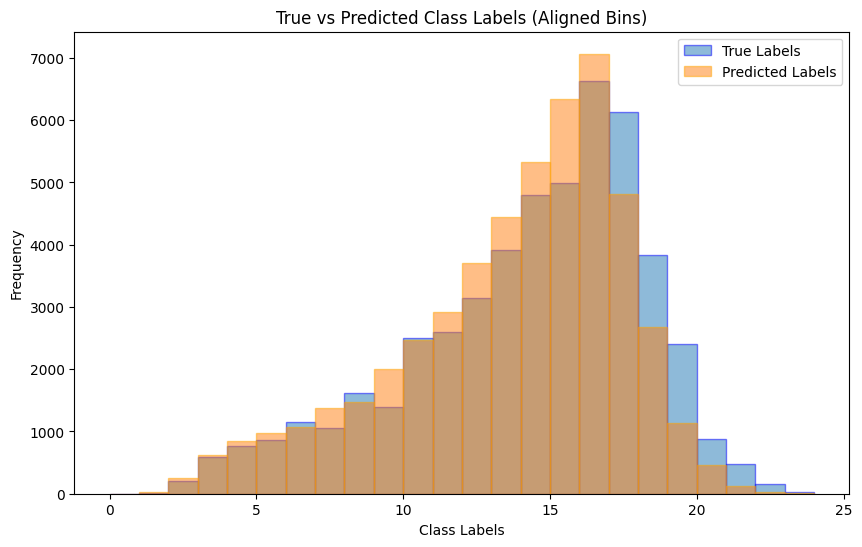

In [8]:
# Best Parameters Found:
#   n_d: 64
#   n_steps: 3
#   gamma: 1.3761076912492625
#   lambda_sparse: 0.0003332282653799267
#   lr: 0.016220882600581313


Tabnet_height = TabNetRegressor(
    n_d= 64,
    n_a= 64,
    n_steps= 3,
    gamma= 1.3761076912492625,
    lambda_sparse= 0.0003332282653799267,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.016220882600581313),
    mask_type='entmax',
    device_name='cuda',
    verbose=1
)

Tabnet_height.fit(
    X_train=AEF_train_np, y_train=aef_train_np,
    eval_set=[(AEF_val_np, aef_val_np)],
    eval_name=['valid'],
    eval_metric=['rmse'],
    max_epochs=150,
    patience=20,
    batch_size=4096,
    virtual_batch_size=512
)

# Evaluate
print("\nEvaluating Final Model on Test Set...")
y_pred_final = Tabnet_height.predict(AEF_test_np)

rmse_final = np.sqrt(mean_squared_error(aef_test_np, y_pred_final))
mae_final = mean_absolute_error(aef_test_np, y_pred_final)

print(f"Final Tabnet Model RMSE: {rmse_final:.3f}")
print(f"Final Tabnet Model MAE: {mae_final:.3f}")

# Plot
plt.figure(figsize=(10, 6))

# Force bins to be exactly 0, 1, 2, ..., 24
shared_bins = np.arange(0, 25, 1)

plt.hist(aef_test_np, label='True Labels', alpha=0.5, bins=shared_bins, edgecolor='blue')
plt.hist(y_pred_final, label='Predicted Labels', alpha=0.5, bins=shared_bins, edgecolor='orange')

plt.xlabel('Class Labels')
plt.ylabel('Frequency')
plt.legend()
plt.title('True vs Predicted Class Labels (Aligned Bins)')
plt.show()

# Feature Importance Analyses on Alpha Earth Foundation + Sentinel-2 dataset

## XGBoost SHAP value

In [13]:
feature_names = AEF_train.columns.tolist()

print("Initializing SHAP TreeExplainer...")
explainer = shap.TreeExplainer(XGBmodel_height)

print("Calculating SHAP values...")
shap_values = explainer.shap_values(AEF_test)

Initializing SHAP TreeExplainer...
Calculating SHAP values...


### Top 20 Features

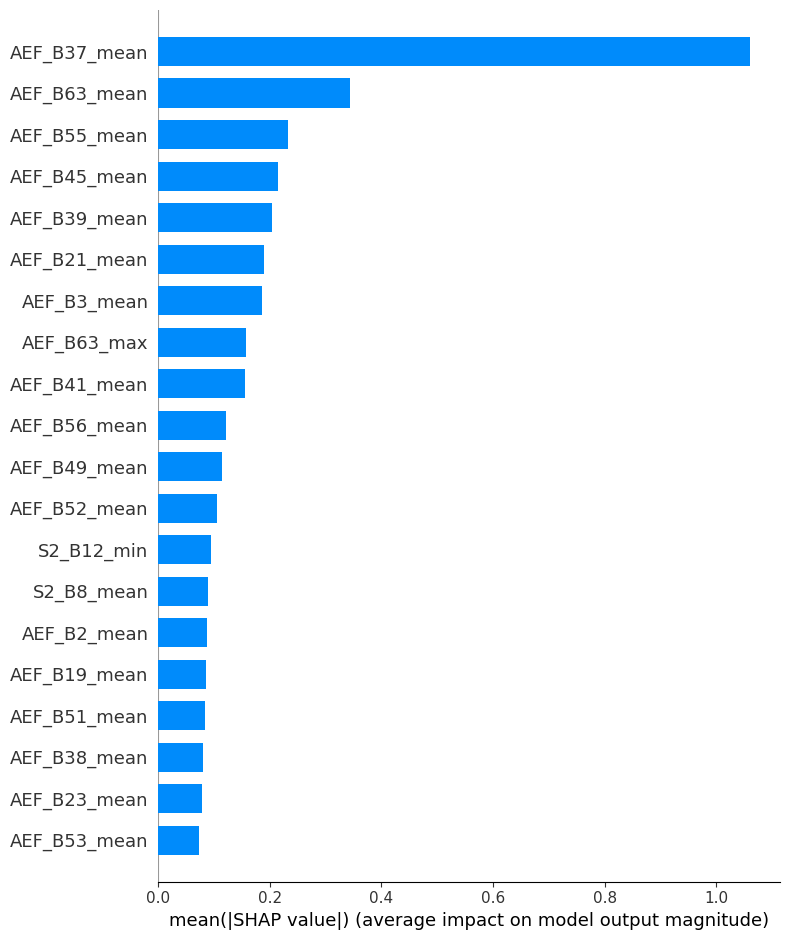

In [14]:
shap.summary_plot(shap_values, AEF_test, feature_names=feature_names, plot_type="bar")

### Top 100 Features

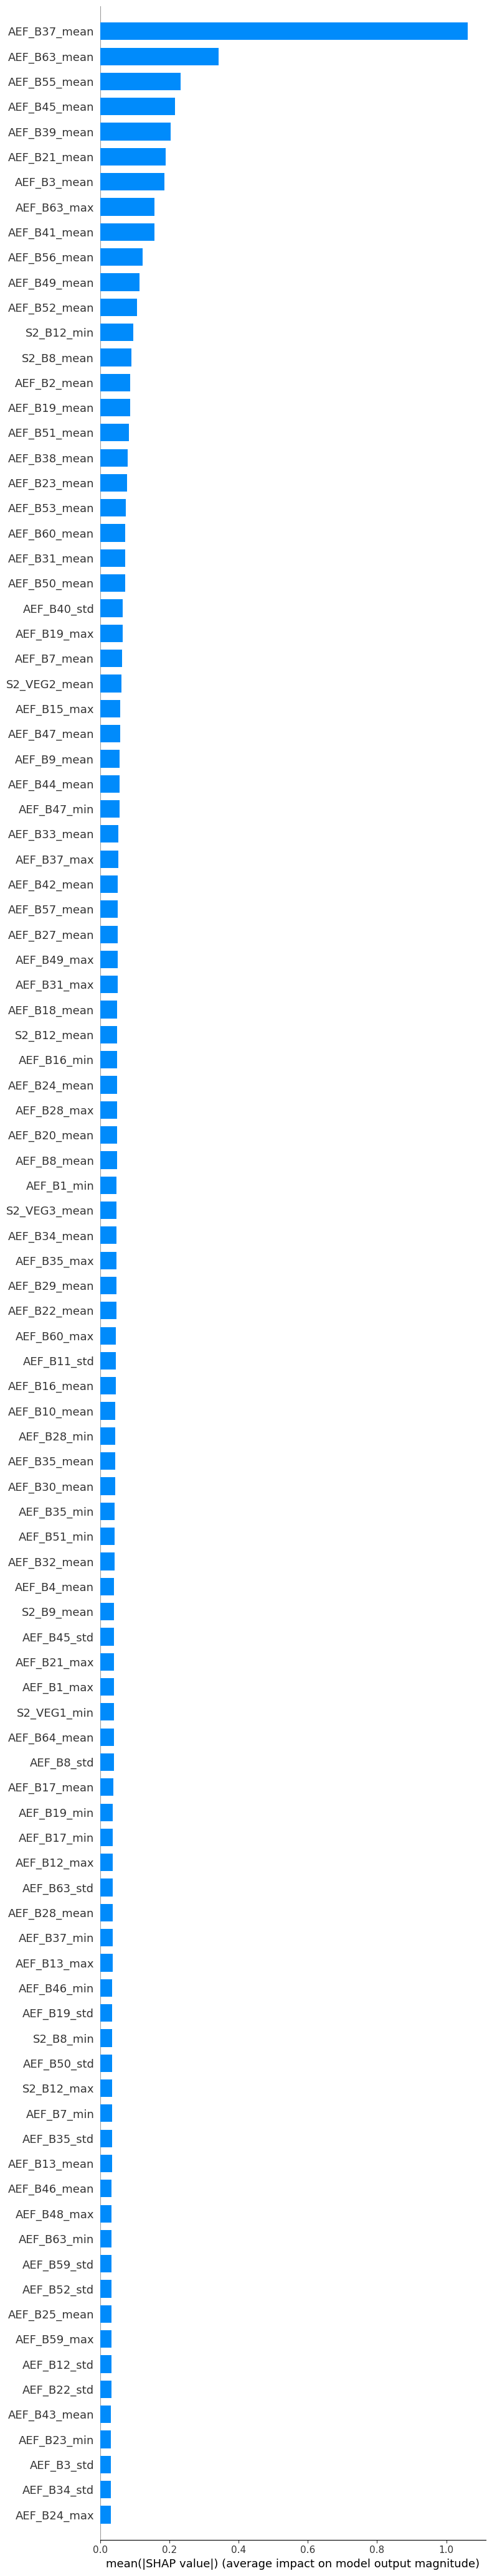

In [15]:
shap.summary_plot(shap_values, AEF_test, feature_names=feature_names, plot_type="bar", max_display=100)

## Tabnet SHAP value

In [16]:
import shap

feature_names = AEF_train.columns.tolist()

# Create a small "Test" sample to explain
test_indices = np.random.choice(AEF_test_np.shape[0], 2000, replace=False)
X_test_sample = AEF_test_np[test_indices]

# Initialize the SHAP Explainer
print("Initializing SHAP Explainer...")
explainer = shap.KernelExplainer(
    lambda x: Tabnet_height.predict(x).flatten(),
    shap.kmeans(AEF_train_np, 100)
)

# Calculate SHAP values for the test sample
print("Calculating SHAP values...")
shap_values = explainer.shap_values(X_test_sample)

Initializing SHAP Explainer...
Calculating SHAP values...


  0%|          | 0/2000 [00:00<?, ?it/s]

### Top 20 Features

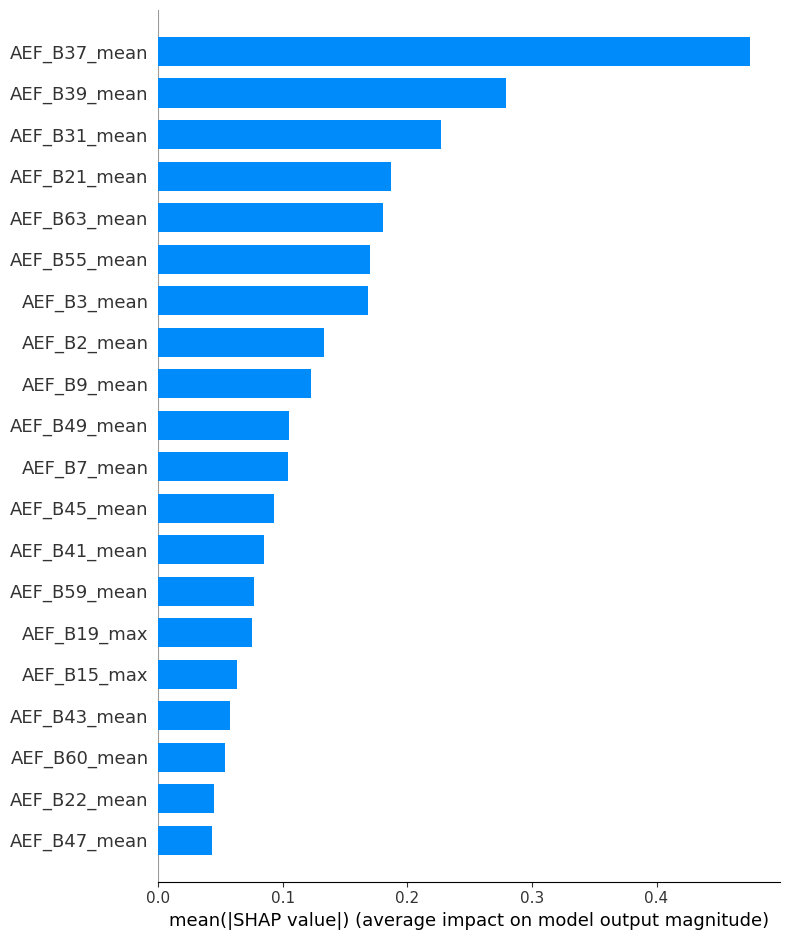

In [17]:
shap.summary_plot(shap_values, AEF_test_np, feature_names=feature_names, plot_type="bar")

### Top 100 Features

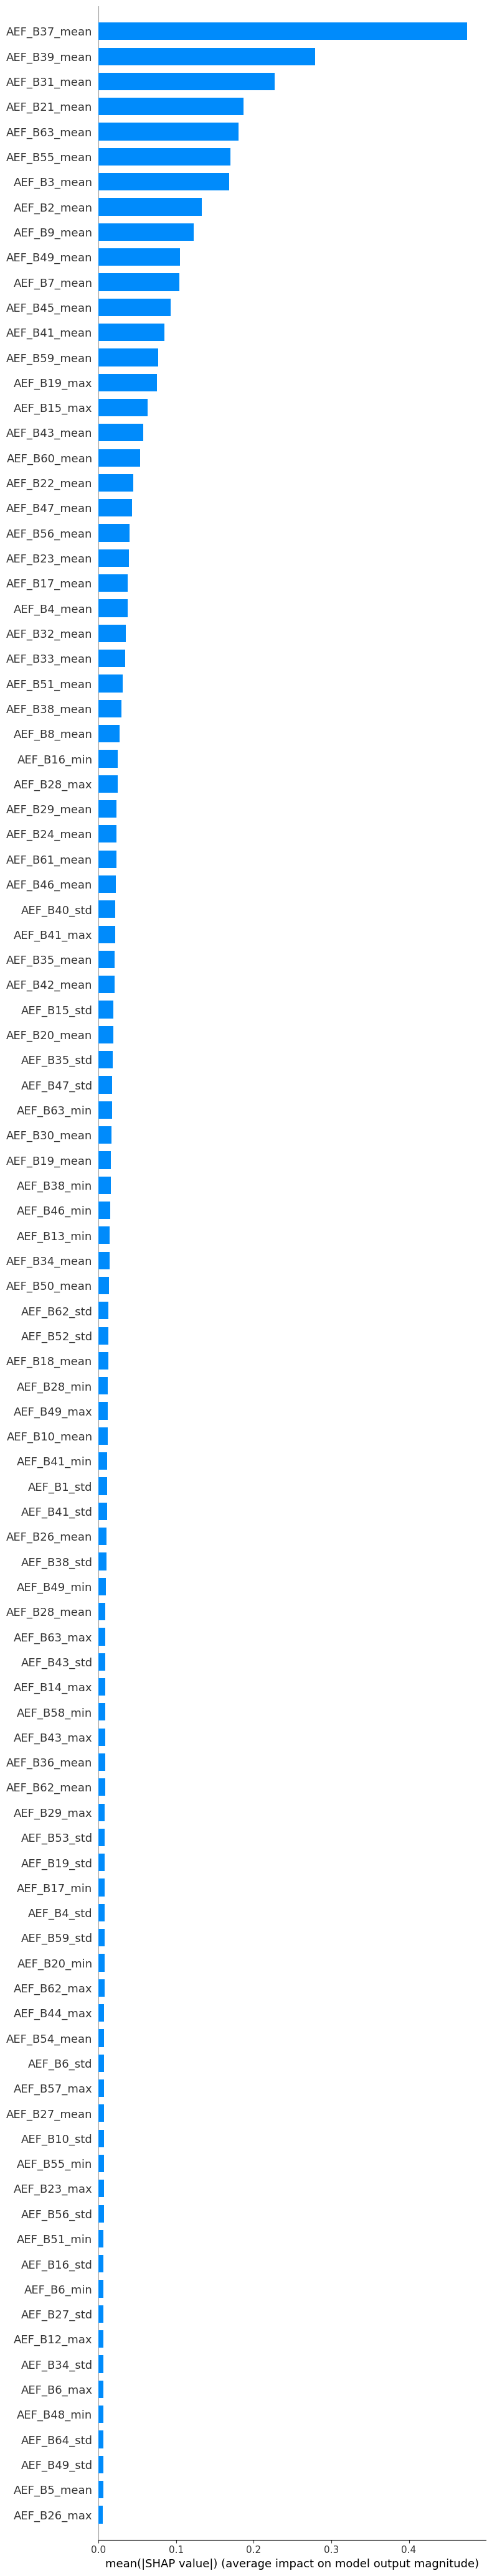

In [18]:
shap.summary_plot(shap_values, AEF_test_np, feature_names=feature_names, plot_type="bar", max_display = 100)